1. Data Preparation
- Load the CSV file with metadata
- Create binary labels: consolidate health categories into "healthy" vs "unhealthy" (everything else)
- Load images from the bee_imgs/ folder based on filenames in CSV

2. Feature Extraction from Images
Random Forest can't work with raw images directly - you need to extract features first
Options:
- Hand-crafted features: Color histograms, texture features (HOG, LBP), edge features
- Pre-trained CNN features: Use a pre-trained model (ResNet, VGG, etc.) as a feature extractor, then feed those features to Random Forest
- Simple statistical features: Mean/std of RGB channels, image moments

3. Data Splitting
- Split into train/test sets (80/20 or similar)
- Ensure stratified split to maintain class balance
- Keep random state consistent for reproducibility

4. Check Class Distribution
- Analyze healthy vs unhealthy counts
- If imbalanced, plan handling (class weights, SMOTE, etc.)

5. Feature Scaling
- Normalize/standardize extracted features (Random Forest is less sensitive but still helps)

6. Model Training
- Build Random Forest classifier
- Consider hyperparameters: n_estimators, max_depth, min_samples_split
- Optionally use GridSearchCV or RandomizedSearchCV for tuning

7. Model Evaluation
- Accuracy, precision, recall, F1-score
- Confusion matrix
- ROC curve and AUC
- Feature importance analysis

8. Results Visualization
- Plot confusion matrix
- Feature importance bar chart
- Model performance metrics comparison

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

## 1. Data Preparation

In [ ]:
# Load the CSV file with metadata
bee_data = pd.read_csv("../data/processed/processed_bee_data_20260316_183549.csv", sep=';')
print(bee_data.head())

In [ ]:
# Necessary features (X) and target (y)
x = bee_data[['file']].copy()
y = bee_data['health'].copy()

# Use the predefined split groups from processed metadata
split_col = bee_data['split_group'].str.lower()

x_train = x[split_col == 'train']
y_train = y[split_col == 'train']

x_val = x[split_col == 'val']
y_val = y[split_col == 'val']

x_test = x[split_col == 'test']
y_test = y[split_col == 'test']

# Shape / # rows, # columns for each split
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_val shape: {x_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Number of unique classes
num_classes_train = len(np.unique(y_train))
num_classes_val = len(np.unique(y_val))
num_classes_test = len(np.unique(y_test))

print(f"Number of classes in training set: {num_classes_train}")
print(f"Number of classes in validation set: {num_classes_val}")
print(f"Number of classes in test set: {num_classes_test}")

print(bee_data[['file', 'split_group']].head(10))
print(bee_data['split_group'].value_counts())

Original health categories:
['hive being robbed' 'healthy' 'few varrao, hive beetles' 'ant problems'
 'missing queen' 'Varroa, Small Hive Beetles']

Original class distribution:
health
healthy                       3384
few varrao, hive beetles       579
Varroa, Small Hive Beetles     472
ant problems                   457
hive being robbed              251
missing queen                   29
Name: count, dtype: int64

Binary class distribution:
binary_health
healthy      3384
unhealthy    1788
Name: count, dtype: int64


We can see that we have:
healthy      3384
unhealthy    1788
bees...
This will definitely benefit from undersampling the healthy class.

## 2. Feature preparation, split

In [ ]:
# Preparation of features (X) and binary target (y)
x = bee_data[['file']]  # We'll only need the filename to load images
y = bee_data['binary_health'] # binary target

# Split data into train (80%) and test (20%)
# Stratified split to maintain class balance -> ratio of healthy vs unhealthy (we can see the ratio at the bottom)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Shape / # rows, # columns for the training and test sets
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Check binary class distribution in train and test sets
print("\n" + "="*50)
print("Training set class distribution:")
print(y_train.value_counts())

print("\nTest set class distribution:")
print(y_test.value_counts())

# Calculate percentages
print("\n" + "="*50)
print("Training set percentages:")
print(y_train.value_counts(normalize=True) * 100) # normalize to see actual ratios

print("\nTest set percentages:")
print(y_test.value_counts(normalize=True) * 100)

x_train shape: (4137, 1)
y_train shape: (4137,)
x_test shape: (1035, 1)
y_test shape: (1035,)

Training set class distribution:
binary_health
healthy      2707
unhealthy    1430
Name: count, dtype: int64

Test set class distribution:
binary_health
healthy      677
unhealthy    358
Name: count, dtype: int64

Training set percentages:
binary_health
healthy      65.433889
unhealthy    34.566111
Name: proportion, dtype: float64

Test set percentages:
binary_health
healthy      65.410628
unhealthy    34.589372
Name: proportion, dtype: float64


we can see that because of stratification, the ratios of about 65.4 on training set and 34.6 on test set were maintained.

Now we could handle this with setting class weights undersampling majority class (heakthy) or undersampling the minority class (unhealthy).

Creating class weights to solve unbalance problem.

In [ ]:
# When training the Random Forest later, use class_weight parameter
# Auto-penalization of minority class


class_weights = compute_class_weight('balanced', 
                                      classes=np.unique(y_train),
                                      y=y_train)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print("Class weights:")
print(class_weight_dict)

Class weights:
{'healthy': np.float64(0.764130033247137), 'unhealthy': np.float64(1.4465034965034964)}


In [16]:
# Load images from the bee_imgs/ folder based on filenames from the .csv file

# Same function as in cnn, to load an image from the bee_imgs folder
def load_image(filename):
    img_path = os.path.join("../data/bee_imgs", filename) # join directory name with filename
    return np.array(Image.open(img_path)) # return Image pixel data as numpy array

# Load all images from the training set as a list
x_train_images = []
for i in range(len(x_train)):
    x_train_images.append(load_image(x_train.iloc[i, 0])) # get filename: 0-th column, i-th row
print(f"Loaded {len(x_train_images)} training images")

# Load all images from the test set
x_test_images = []
for i in range(len(x_test)):
    x_test_images.append(load_image(x_test.iloc[i, 0]))
print(f"Loaded {len(x_test_images)} test images")

Loaded 4137 training images
Loaded 1035 test images


Feature Extraction and Feature Scaling


Exxtract fix-size image features (simple resized pixel intensities + color statistics), and then standardize them before training the Random Forest model.

Random Forest (classic ML) can't work directly with raw image pixel data (unlike CNN). Images are high-dimensional that would require millions of features. Feature extraction converts images into a smaller, more meaningful set of numbers that capture the important information.

In [ ]:
# Feature extraction helper

# image size 128x128 as in cnn
def extract_features(images, target_size=(128, 128)):
    features = []
    for img in images:
        # Ensure RGB and consistent size
        pil_img = Image.fromarray(img).convert("RGB").resize(target_size)
        arr = np.asarray(pil_img, dtype=np.float32) / 255.0

        # Flatten pixels: basically taking their multi dimensionality into account and putting them into a 1-dimensional row of numbers
        flat = arr.flatten()
        
        # Add simple color stats (mean/std per channel) = 3 mean + 3 std per channel
        means = arr.mean(axis=(0, 1))
        stds = arr.std(axis=(0, 1))
        feat = np.concatenate([flat, means, stds])
        features.append(feat)
    return np.vstack(features) # vertically "stack" or organize the features numbers

# Extract features
x_train_features = extract_features(x_train_images)
x_test_features = extract_features(x_test_images)

print(f"x_train_features shape: {x_train_features.shape}")
print(f"x_test_features shape: {x_test_features.shape}")

# Feature scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_features)
x_test_scaled = scaler.transform(x_test_features)

x_train_features shape: (4137, 49158)
x_test_features shape: (1035, 49158)


Images 128x128x3 + 6: 49 152 + 6
Meaning one feature for every pixel and rgb value + 3 mean and + 3 std per channel
Now we have a proper 2D matrix

In [17]:
# Model training: Random Forest
use_grid_search = False  # set to True for hyperparameter tuning later

# taken from websites, hyperparameter tuning later
if use_grid_search:
    param_grid = {
        "n_estimators": [100, 200, 300], # number of decision trees in random forest
        "max_depth": [None, 10, 20], # tree depth
        "min_samples_split": [2, 5, 10] # minimum trees required to split node
    }
    base_rf = RandomForestClassifier(
        random_state=42,
        class_weight=class_weight_dict,
        n_jobs=-1
    )
    grid = GridSearchCV(
        estimator=base_rf,
        param_grid=param_grid,
        cv=3,
        scoring="f1",
        n_jobs=-1,
        verbose=1
    )
    grid.fit(x_train_scaled, y_train)
    rf_model = grid.best_estimator_
    print("Best params:", grid.best_params_)
else:
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        random_state=42,
        class_weight=class_weight_dict,
        n_jobs=-1
    )
    rf_model.fit(x_train_scaled, y_train)
    print("Random Forest trained with default hyperparameters.")

Random Forest trained with default hyperparameters.


Model Evaluation and Results Visualization


Evaluating the trained model on the test set, plotting the confusion matrix and AOC-ROC curve, and inspect feature importances.

Classification Report:
              precision    recall  f1-score   support

     healthy       0.91      0.99      0.95       677
   unhealthy       0.97      0.82      0.88       358

    accuracy                           0.93      1035
   macro avg       0.94      0.90      0.92      1035
weighted avg       0.93      0.93      0.92      1035


Summary Metrics:
Accuracy: 0.9266
Precision (unhealthy): 0.9669
Recall (unhealthy): 0.8156
F1-score (unhealthy): 0.8848


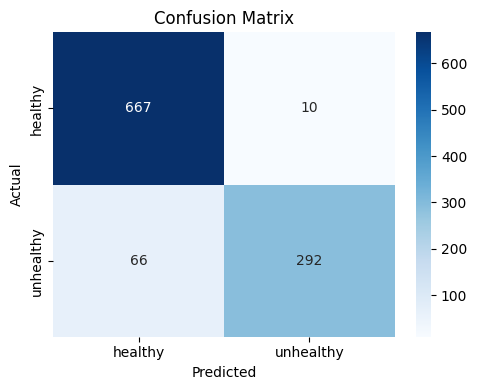

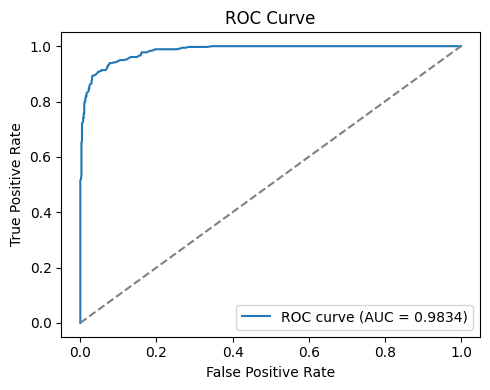

In [ ]:
# Predictions
y_pred = rf_model.predict(x_test_scaled)

# If predict_proba is available, use it for ROC/AUC
# basically the probability of the unhealthy class
y_proba = None
if hasattr(rf_model, "predict_proba"):
    y_proba = rf_model.predict_proba(x_test_scaled)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label="unhealthy")
rec = recall_score(y_test, y_pred, pos_label="unhealthy")
f1 = f1_score(y_test, y_pred, pos_label="unhealthy")

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("\nSummary Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (unhealthy): {prec:.4f}")
print(f"Recall (unhealthy): {rec:.4f}")
print(f"F1-score (unhealthy): {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["healthy", "unhealthy"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["healthy", "unhealthy"], yticklabels=["healthy", "unhealthy"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve and AUC
if y_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label="unhealthy")
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("ROC/AUC not available: model does not support predict_proba.")

Precision: When it says 1 how often is it right
Recall/Sensitivity: What fraction of 1s does it get right (True Positive Rate – TPR)
F1score: How “good” are precision and recall


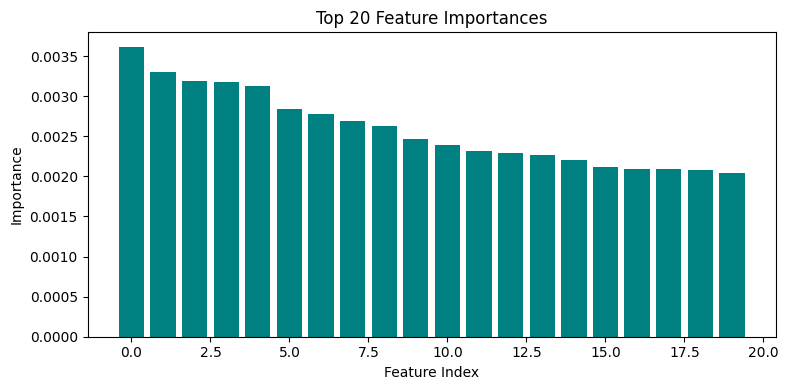

,accuracy,precision_unhealthy,recall_unhealthy,f1_unhealthy,roc_auc
0,0.92657,0.966887,0.815642,0.884848,0.983405


In [12]:
# Feature importance (top 20)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

top_n = 20
top_indices = indices[:top_n]
top_importances = importances[top_indices]

plt.figure(figsize=(8, 4))
plt.bar(range(top_n), top_importances, color="teal")
plt.title("Top 20 Feature Importances")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# Summarize results
summary = {
    "accuracy": acc,
    "precision_unhealthy": prec,
    "recall_unhealthy": rec,
    "f1_unhealthy": f1,
}
if y_proba is not None:
    summary["roc_auc"] = roc_auc
pd.DataFrame([summary])

The result from the feature importance tells us little as to what is actually important. Since we have number values for our images, it's hard to distinguishh features, we don't have them clear cut.

They are most likely pixel values and the mean + std channels

Try out Random forest, with Grid search and evaluate again